In [2]:
import pandas as pd
df=pd.read_csv('diabetes.csv')
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [3]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [5]:
cat=[]
con=[]
for i in df.columns :
    if df[i].dtype=='object':
        cat.append(i)
    else:
        con.append(i)
        

In [72]:
cat

[]

In [73]:
con

['Pregnancies',
 'Glucose',
 'BloodPressure',
 'SkinThickness',
 'Insulin',
 'BMI',
 'DiabetesPedigreeFunction',
 'Age',
 'Outcome']

In [74]:


def replacer(df,cols):
    for i in cols:
        df[i]=df[i].replace(0,df[i].mean())
    return df    

In [77]:
df = replacer(df, con)

In [78]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6.000000,148.0,72.0,35.000000,79.799479,33.6,0.627,50,1.000000
1,1.000000,85.0,66.0,29.000000,79.799479,26.6,0.351,31,0.348958
2,8.000000,183.0,64.0,20.536458,79.799479,23.3,0.672,32,1.000000
3,1.000000,89.0,66.0,23.000000,94.000000,28.1,0.167,21,0.348958
4,3.845052,137.0,40.0,35.000000,168.000000,43.1,2.288,33,1.000000


In [79]:
X=df.drop(columns='Outcome',axis=1)
y=df['Outcome']

In [80]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=42)

In [81]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras import Input

In [82]:
ss=StandardScaler()
x_train=ss.fit_transform(x_train)
x_test=ss.transform(x_test)

In [83]:
model=Sequential(
    [
        Input(shape=(x_train.shape[1],)),
        Dense(8,activation='relu'),
        Dense(4,activation='relu'),
        Dense(1,activation='sigmoid')

        
    ]
)

In [84]:
from tensorflow.keras.metrics import Recall,Precision,BinaryAccuracy
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        BinaryAccuracy(name='Accuracy'),
        Precision(name='Precision'),
        Recall(name='recall')
    ]
)

In [85]:
history=model.fit(x_train,y_train,epochs=20,batch_size=16,validation_data=(x_test,y_test))

Epoch 1/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - Accuracy: 0.3469 - Precision: 1.0000 - loss: 0.6889 - recall: 1.0000 - val_Accuracy: 0.3571 - val_Precision: 1.0000 - val_loss: 0.6834 - val_recall: 1.0000
Epoch 2/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - Accuracy: 0.3469 - Precision: 1.0000 - loss: 0.6810 - recall: 1.0000 - val_Accuracy: 0.3571 - val_Precision: 1.0000 - val_loss: 0.6747 - val_recall: 1.0000
Epoch 3/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - Accuracy: 0.3469 - Precision: 1.0000 - loss: 0.6727 - recall: 1.0000 - val_Accuracy: 0.3571 - val_Precision: 1.0000 - val_loss: 0.6658 - val_recall: 1.0000
Epoch 4/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - Accuracy: 0.3469 - Precision: 1.0000 - loss: 0.6652 - recall: 1.0000 - val_Accuracy: 0.3571 - val_Precision: 1.0000 - val_loss: 0.6586 - val_recall: 1.0000
Epoch 5/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - Accuracy: 0.3469 - Precision: 1.0000 - loss: 0.6577 - recall: 1.0000 - val_Accuracy: 0.3571 - val_Precision: 1.000

In [86]:

loss,accuracy,precision,recall=model.evaluate(x_test,y_test)

print("Test Loss      :", loss)
print("Test Accuracy  :", accuracy)
print("Test Precision :", precision)
print("Test Recall    :", recall)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - Accuracy: 0.2857 - Precision: 1.0000 - loss: 0.6304 - recall: 0.5779
Test Loss      : 0.6304304599761963
Test Accuracy  : 0.2857142984867096
Test Precision : 1.0
Test Recall    : 0.5779221057891846


In [88]:
y_prob = model.predict(x_test)

y_pred = (y_prob >= 0.5).astype(int).ravel()

import numpy as np

y_test = np.array(y_test).astype(int).ravel()

print("y_test:", np.unique(y_test))
print("y_pred:", np.unique(y_pred))

1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/stepWARNING:tensorflow:5 out of the last 16 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x0000028E73F22700> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
y_test: [0 1]
y_pred: [0 1]


In [89]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Accuracy  :", accuracy_score(y_test, y_pred))
print("Precision :", precision_score(y_test, y_pred))
print("Recall    :", recall_score(y_test, y_pred))
print("F1 Score  :", f1_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))



print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy  : 0.6363636363636364
Precision : 0.4943820224719101
Recall    : 0.8
F1 Score  : 0.6111111111111112

Confusion Matrix:
[[54 45]
 [11 44]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.55      0.66        99
           1       0.49      0.80      0.61        55

    accuracy                           0.64       154
   macro avg       0.66      0.67      0.63       154
weighted avg       0.71      0.64      0.64       154



In [90]:
import matplotlib.pyplot as plt

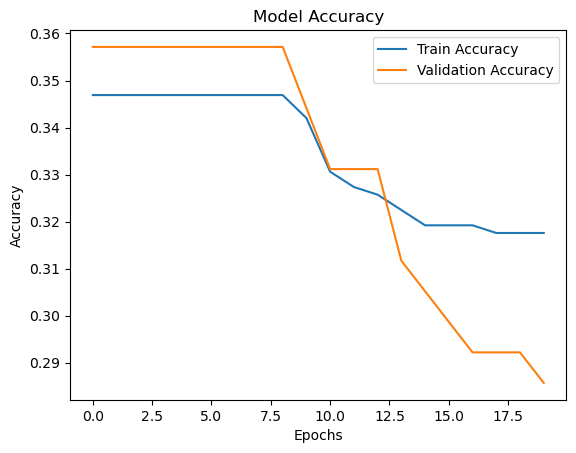

In [91]:
plt.figure()
plt.plot(history.history['Accuracy'])
plt.plot(history.history['val_Accuracy'])

plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.legend(['Train Accuracy','Validation Accuracy'])
plt.show()

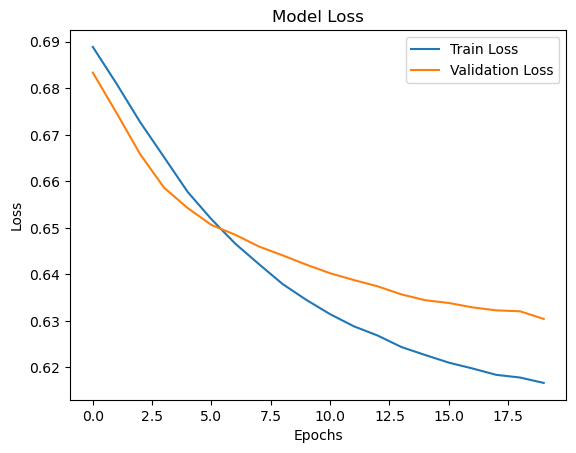

In [92]:
# model loss
import matplotlib.pyplot as plt

plt.figure()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.legend(['Train Loss', 'Validation Loss'])

plt.show()

In [93]:
loss, accuracy, precision, recall = model.evaluate(x_test, y_test)

print("Test Loss      :", loss)
print("Test Accuracy  :", accuracy)
print("Test Precision :", precision)
print("Test Recall    :", recall)


5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - Accuracy: 0.6364 - Precision: 0.4944 - loss: 0.6877 - recall: 0.8000 
Test Loss      : 0.687690019607544
Test Accuracy  : 0.6363636255264282
Test Precision : 0.49438202381134033
Test Recall    : 0.800000011920929


In [94]:
import joblib

joblib.dump(ss, "scaler.pkl")

['scaler.pkl']

In [95]:
model.save("diabetes_model.keras")